In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from iminuit import Minuit
import seaborn as sns
import matplotlib.patches as patches

In [36]:



def setup_plotting(ticksize=14, fontsize=16, figsize=(16, 9), dpi=150):
    """
    Global plotting setup:
    - Seaborn grey background
    - Custom reversed/de-saturated deep palette
    - Serif + STIX math fonts
    - Grid, linewidths, ticks, figure defaults
    """

    # --- Base style (grey background preserved) ---
    plt.style.use("seaborn-v0_8")
    sns.set()
    sns.set_context("paper", font_scale=1.4)
    sns.set_style("ticks")

    # --- Color palette ---
    #colors = sns.color_palette("deep", 10, desat=0.8)
    #colors = sns.color_palette("husl", 10)
    #colors = sns.color_palette("tab10", 10)
    colors = sns.color_palette("Set1", 10)
    #colors = colors[::-1]
    #colors.pop(2)
    sns.set_palette(colors)

    # --- Fonts ---
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman"] + plt.rcParams["font.serif"],
        "mathtext.fontset": "stix",
        "font.size": fontsize,
        "xtick.labelsize": ticksize,
        "ytick.labelsize": ticksize,
    })

    # --- Axes & ticks ---
    plt.rcParams.update({
        "axes.linewidth": 2.25,
        "axes.formatter.limits": (-1, 3),
        "axes.grid": True,
        "legend.facecolor": "white",
    })

    # --- Grid ---
    plt.rcParams.update({
        "grid.linestyle": "--",
        "grid.linewidth": 1.5,
    })

    # --- Figure defaults ---
    plt.rcParams.update({
        "figure.figsize": figsize,
        "figure.dpi": dpi,
    })

    return colors


def stylize_ticks(fig, ax):
    """
    Apply inward ticks, minor ticks, and label offsets
    """

    ax.xaxis.set_tick_params(which="major", direction="in",
                             width=2.5, length=12, top=True)
    ax.yaxis.set_tick_params(which="major", direction="in",
                             width=2.5, length=12, right=True)

    ax.xaxis.set_tick_params(which="minor", direction="in",
                             width=1.5, length=6, top=True)
    ax.yaxis.set_tick_params(which="minor", direction="in",
                             width=1.5, length=6, right=True)

    # Label offsets
    dx = -3 / 72
    dy = -3 / 72
    x_offset = matplotlib.transforms.ScaledTranslation(dx, 0, fig.dpi_scale_trans)
    y_offset = matplotlib.transforms.ScaledTranslation(0, dy, fig.dpi_scale_trans)

    for label in ax.xaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + y_offset)

    for label in ax.yaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + x_offset)
    
    colors = setup_plotting(ticksize=14, fontsize=16, figsize=(16, 9), dpi=150)

In [37]:
data = np.genfromtxt('ParameterEstimation_Ex1.txt')

def func(x,a, b):
    return 1 + a*x + b*x**2
def ln_likelihood(vals, func, a, b):
    pdf_vals = func(vals,a,b)
    return -np.sum(np.log(pdf_vals))

def normalized_function(x,a,b):
    integral, _ = integrate.quad(lambda x: func(x, a, b), -0.95, 0.95)
    return func(x, a, b) / integral 

In [38]:
m = Minuit(lambda a,b: ln_likelihood(data, normalized_function, a, b), a=0, b=0)
m.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1779                       │              Nfcn = 46               │
│ EDM = 4.9e-06 (Goal: 0.0002)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   0.64    │   0.07    │            │            │         │         │       │
│ 1 │ b    │   0.88    │   0.15    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬─────────────────┐
│   │       a       b │
├───┼─────────────────┤
│ a │ 0.00476   0.005 │
│ b │   0.005  0.0236 │
└───┴─────────────────┘

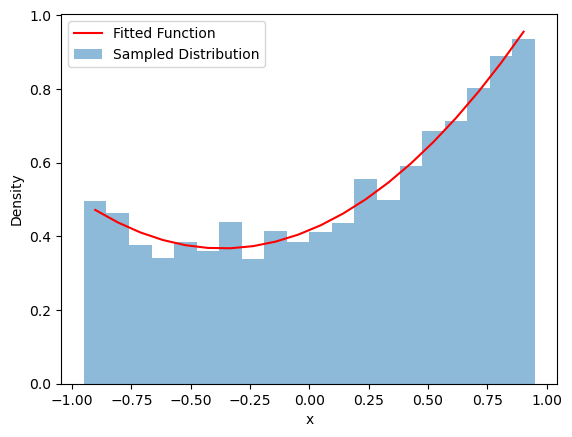

In [39]:
Nbins= 20
x_range = (-0.95, 0.95)
counts, edges = np.histogram(data, bins=Nbins, range=x_range, density=True)
bin_centers = (edges[:-1] + edges[1:]) / 2
plt.bar(bin_centers, counts, width=edges[1] - edges[0], alpha=0.5, label='Sampled Distribution')
plt.plot(bin_centers, normalized_function(bin_centers, m.values['a'], m.values['b']), label='Fitted Function', color='red')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.show()

In [40]:
# sample new datasets from the fitted distribution

N = 1000 #create 1000 datasets
N_points = 3013 # number of points in each dataset
simulated_datasets = []
for _ in range(N):
    dataset = np.array([])
    while len(dataset) < N_points:
        x = np.random.uniform(-0.95, 0.95)
        u = np.random.uniform(0, 1)
        if u < normalized_function(x, m.values['a'], m.values['b']):
            dataset = np.append(dataset, x)
    simulated_datasets.append(dataset)

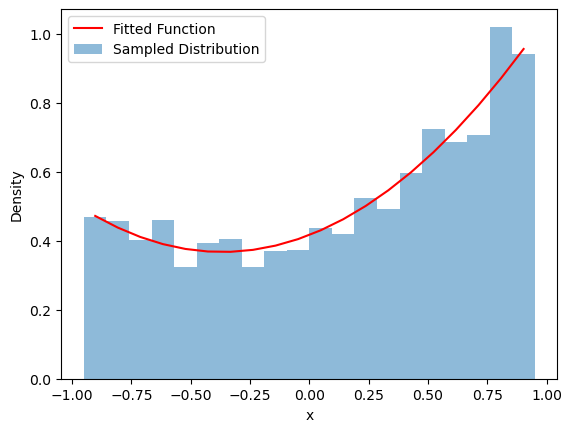

In [41]:
Nbins= 20
x_range = (-0.95, 0.95)
counts, edges = np.histogram(simulated_datasets[1], bins=Nbins, range=x_range, density=True)
bin_centers = (edges[:-1] + edges[1:]) / 2
plt.bar(bin_centers, counts, width=edges[1] - edges[0], alpha=0.5, label='Sampled Distribution')
plt.plot(bin_centers, normalized_function(bin_centers, m.values['a'], m.values['b']), label='Fitted Function', color='red')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.show()

In [42]:
a_trials = np.zeros(N)
b_trials = np.zeros(N)
#likelihood = np.zeros(N)
simulatred_datasets = np.array(simulated_datasets)
for i, dataset in enumerate(simulated_datasets):
    m_trial = Minuit(lambda a,b: ln_likelihood(dataset, normalized_function, a, b), a=0, b=0)
    m_trial.migrad()
    a_trials[i] = m_trial.values['a']
    b_trials[i] = m_trial.values['b']
    #likelihood[i] = ln_likelihood(dataset, normalized_function, m_trial.values['a'], m_trial.values['b'])

In [43]:
likelihood = np.zeros(N)
for i, (a, b) in enumerate(zip(a_trials, b_trials)):
    likelihood[i] = ln_likelihood(data, normalized_function, a, b)

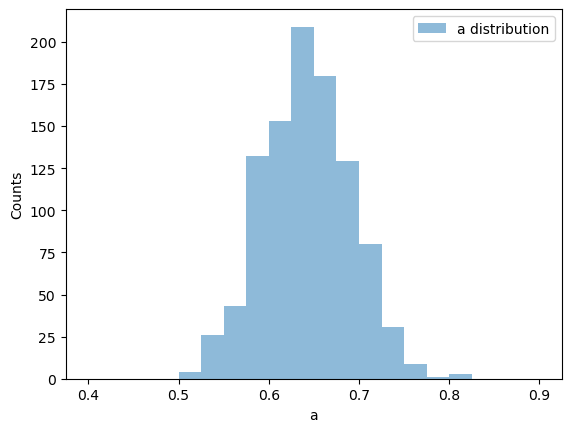

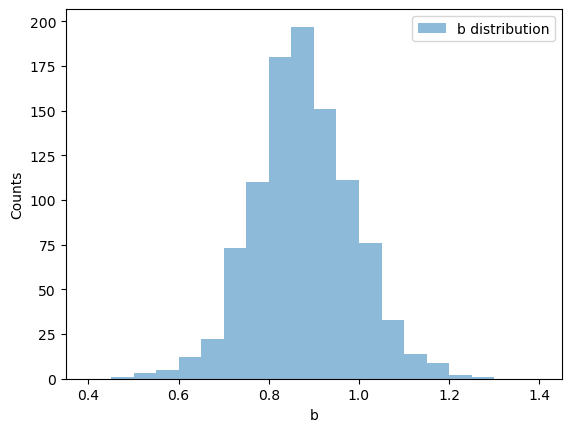

In [44]:
# distributions of a and b
a_range =(0.4,0.9)
b_range = (0.4,1.4) 

counts_a, edges_a = np.histogram(a_trials, bins=20, range=a_range, density=False)
bin_centers_a = (edges_a[:-1] + edges_a[1:]) / 2
plt.bar(bin_centers_a, counts_a, width=edges_a[1] - edges_a[0], alpha=0.5, label='a distribution')
plt.xlabel('a')
plt.ylabel('Counts')
plt.legend()
plt.show()

counts_b, edges_b = np.histogram(b_trials, bins=20, range=b_range, density=False)
bin_centers_b = (edges_b[:-1] + edges_b[1:]) / 2
plt.bar(bin_centers_b, counts_b, width=edges_b[1] - edges_b[0], alpha=0.5, label='b distribution')
plt.xlabel('b')
plt.ylabel('Counts')
plt.legend()
plt.show()

In [48]:

a_1sigma = np.percentile(a_trials, [16, 84])
b_1sigma = np.percentile(b_trials, [16, 84])
a_2sigma = np.percentile(a_trials, [2.5, 97.5])
b_2sigma = np.percentile(b_trials, [2.5, 97.5])
a_3sigma = np.percentile(a_trials, [0.15, 99.85])
b_3sigma = np.percentile(b_trials, [0.15, 99.85])

center_1 = ((a_1sigma[0] + a_1sigma[1]) / 2, (b_1sigma[0] + b_1sigma[1]) / 2)
center_2 = ((a_2sigma[0] + a_2sigma[1]) / 2, (b_2sigma[0] + b_2sigma[1]) / 2)
center_3 = ((a_3sigma[0] + a_3sigma[1]) / 2, (b_3sigma[0] + b_3sigma[1]) / 2)
a_1sigma_width = a_1sigma[1] - a_1sigma[0]
b_1sigma_width = b_1sigma[1] - b_1sigma[0]
a_2sigma_width = a_2sigma[1] - a_2sigma[0]
b_2sigma_width = b_2sigma[1] - b_2sigma[0]
a_3sigma_width = a_3sigma[1] - a_3sigma[0]
b_3sigma_width = b_3sigma[1] - b_3sigma[0]

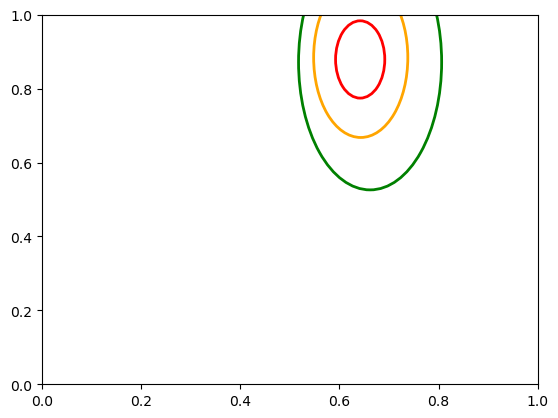

In [50]:
fig, ax = plt.subplots()


ellipse = patches.Ellipse(
    xy=center_1,      # Center of ellipse
    width=a_1sigma_width,                      # Width (along x-axis)
    height=b_1sigma_width,                     # Height (along y-axis)
    angle=0,           # Rotation in degrees
    linewidth=2,
    edgecolor='red',
    facecolor='none'                # No fill, just outline
)
ax.add_patch(ellipse)

ellipse = patches.Ellipse(
    xy=center_2,      # Center of ellipse
    width=a_2sigma_width,                      # Width (along x-axis)
    height=b_2sigma_width,                     # Height (along y-axis)
    angle=0,           # Rotation in degrees
    linewidth=2,
    edgecolor='orange',
    facecolor='none'                # No fill, just outline
)
ax.add_patch(ellipse)

ellipse = patches.Ellipse(
    xy=center_3,      # Center of ellipse
    width=a_3sigma_width,                      # Width (along x-axis)
    height=b_3sigma_width,                     # Height (along y-axis)
    angle=0,           # Rotation in degrees
    linewidth=2,
    edgecolor='green',
    facecolor='none'                # No fill, just outline
)
ax.add_patch(ellipse)

plt.show()

TypeError: Input z must be 2D, not 1D

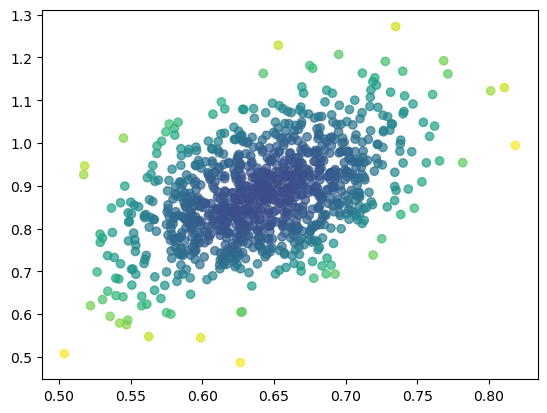

In [51]:
a_trials =np.array(a_trials)
b_trials = np.array(b_trials)
field = likelihood - np.min(likelihood) 

plt.scatter(a_trials, b_trials, c = likelihood, cmap='viridis', vmin=1777, vmax=1785, alpha=0.7)
plt.contour(a_trials, b_trials, field, levels=1.15, cmap='viridis', vmin=1777, vmax=1785)
plt.xlabel('a')
plt.ylabel('b')
plt.title('Correlation between a and b')
plt.xlim(a_range)
plt.ylim(b_range)
plt.colorbar(label='Negative Log-Likelihood')
plt.grid()
plt.show()

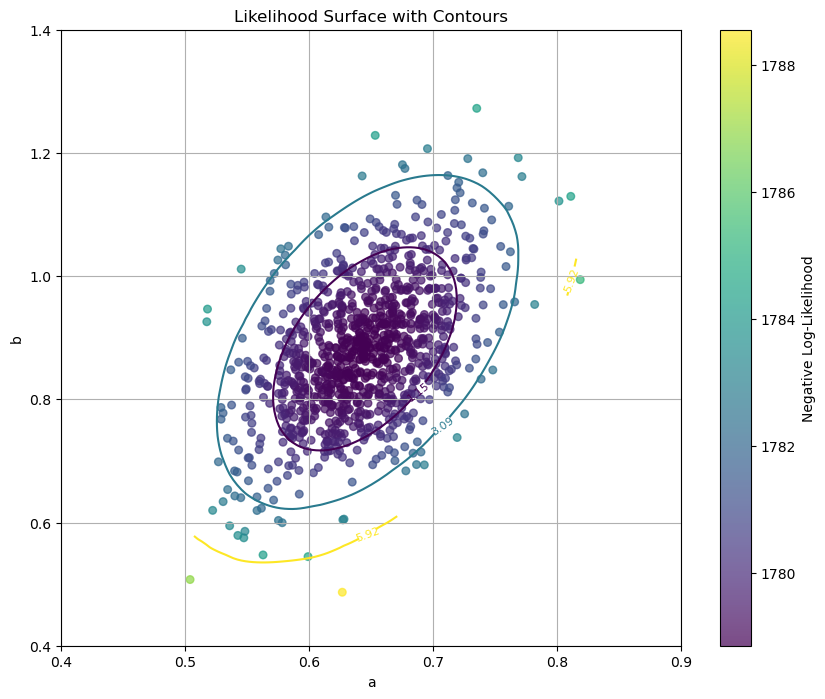

In [59]:
from scipy.interpolate import griddata

a_trials = np.array(a_trials)
b_trials = np.array(b_trials)
likelihood = np.array(likelihood)
field = likelihood - np.min(likelihood)

# Define your regular grid
a_grid = np.linspace(a_trials.min(), a_trials.max(), 100)
b_grid = np.linspace(b_trials.min(), b_trials.max(), 100)
A, B = np.meshgrid(a_grid, b_grid)

# Interpolate likelihood onto the grid
Z = griddata((a_trials, b_trials), field, (A, B), method='cubic')

# Now you can use contour
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(a_trials, b_trials, c=likelihood, cmap='viridis', alpha=0.7, s=30)
contour = ax.contour(A, B, Z, levels=[1.15,3.09, 5.92], cmap='viridis', linewidths=1.5)
ax.clabel(contour, inline=True, fontsize=8)

ax.set_xlabel('a')
ax.set_ylabel('b')
ax.set_title('Likelihood Surface with Contours')
plt.colorbar(scatter, label='Negative Log-Likelihood')
ax.set_xlim(a_range)
ax.set_ylim(b_range)
ax.grid()
plt.show()